# ACERLIM — Prediccion de Demanda de Calaminas
## Modelo de Redes Neuronales (LSTM) | Comparacion con Random Forest

---

**Objetivo:** Predecir la demanda mensual de productos terminados (calaminas) utilizando una Red Neuronal Recurrente de tipo LSTM (Long Short-Term Memory), y comparar los resultados obtenidos contra el modelo base de Random Forest.

**Dataset:** Datos simulados 2023-2025 alineados al schema de la base de datos de ACERLIM.

| Parametro | Valor |
|-----------|-------|
| Periodo de entrenamiento | 2023 - 2024 |
| Periodo de validacion | 2025 |
| Modelo | Red Neuronal LSTM (Keras/TensorFlow) |
| Moneda | BOB (Bolivianos) |

---
## SECCION 1 — Instalacion de Librerias

Instalamos TensorFlow (que incluye Keras) junto con las librerias de datos y visualizacion necesarias para el proyecto.

| Libreria | Uso |
|----------|-----|
| tensorflow / keras | Construccion y entrenamiento de la red neuronal LSTM |
| pandas / numpy | Manipulacion y transformacion de datos |
| scikit-learn | Metricas de evaluacion y preprocesamiento (escalado) |
| matplotlib | Visualizaciones graficas |

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib -q
print('Librerias instaladas correctamente')

Librerias instaladas correctamente



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\elvis\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## SECCION 2 — Importacion de Librerias

Importamos todos los modulos organizados por categoria: datos, modelo neuronal, preprocesamiento y visualizacion.

In [2]:
# -- Datos --
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# -- Red Neuronal --
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -- Preprocesamiento --
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -- Visualizacion --
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('Todas las librerias importadas correctamente')
print(f'  TensorFlow  {tf.__version__}')
print(f'  pandas      {pd.__version__}')
print(f'  numpy       {np.__version__}')

Todas las librerias importadas correctamente
  TensorFlow  2.21.0
  pandas      3.0.2
  numpy       2.4.4


---
## SECCION 3 — Carga de Datos CSV

Cargamos los archivos CSV necesarios desde la carpeta data/. Utilizamos los mismos datos que el modelo Random Forest para una comparacion justa.

In [3]:
BASE = 'data/'

pedidos       = pd.read_csv(BASE + 'pedidos.csv',        parse_dates=['fecha'])
detalles      = pd.read_csv(BASE + 'pedido_detalles.csv')
productos     = pd.read_csv(BASE + 'productos.csv')
tipos         = pd.read_csv(BASE + 'tipos_productos.csv')

print('Archivos cargados:')
print(f'  pedidos          -> {len(pedidos):>5} registros')
print(f'  pedido_detalles  -> {len(detalles):>5} registros')
print(f'  productos        -> {len(productos):>5} registros')
print(f'  tipos_productos  -> {len(tipos):>5} registros')

Archivos cargados:
  pedidos          ->   679 registros
  pedido_detalles  ->  1633 registros
  productos        ->    20 registros
  tipos_productos  ->     5 registros


---
## SECCION 4 — Construccion del Dataset Maestro

Realizamos la union de tablas y agrupamos los datos a nivel mensual por tipo de calamina. Se generan variables temporales y de memoria historica (lags) para alimentar la red neuronal.

In [4]:
# -- Union de tablas --
df = detalles.merge(pedidos[['id_pedido', 'fecha', 'estado_pedido']], on='id_pedido')
df = df[df['estado_pedido'] != 'cancelado'].copy()
df = df.merge(productos[['id_producto', 'id_tipo_producto']], on='id_producto')
df = df.merge(tipos[['id_tipo_producto', 'nombre']].rename(columns={'nombre': 'tipo_calamina'}), on='id_tipo_producto')

df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce').fillna(0).astype(int)
df['fecha'] = pd.to_datetime(df['fecha'])
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month

# -- Agregar a nivel mensual por tipo de calamina --
df_mensual = (
    df.groupby(['anio', 'mes', 'tipo_calamina'])['cantidad']
    .sum()
    .reset_index()
    .rename(columns={'cantidad': 'demanda_total'})
    .sort_values(['tipo_calamina', 'anio', 'mes'])
)

# -- Variables temporales --
df_mensual['temporada'] = df_mensual['mes'].apply(lambda m: 1 if 4 <= m <= 10 else 0)
df_mensual['mes_sin'] = np.sin(2 * np.pi * df_mensual['mes'] / 12)
df_mensual['mes_cos'] = np.cos(2 * np.pi * df_mensual['mes'] / 12)

# -- Lags (memoria historica) --
for lag in [1, 2, 3]:
    df_mensual[f'lag_{lag}'] = (
        df_mensual.groupby('tipo_calamina')['demanda_total'].shift(lag)
    )

# -- Media movil 3 meses --
df_mensual['media_movil_3'] = (
    df_mensual.groupby('tipo_calamina')['demanda_total']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# -- Eliminar filas sin lags --
df_modelo = df_mensual.dropna().copy()

# -- Codificar tipo de calamina --
df_modelo = pd.get_dummies(df_modelo, columns=['tipo_calamina'])

print(f'Dataset mensual construido: {len(df_modelo)} registros')
print(f'Columnas: {list(df_modelo.columns)}')

Dataset mensual construido: 158 registros
Columnas: ['anio', 'mes', 'demanda_total', 'temporada', 'mes_sin', 'mes_cos', 'lag_1', 'lag_2', 'lag_3', 'media_movil_3', 'tipo_calamina_Calamina Ondulada', 'tipo_calamina_Calamina Prepintada', 'tipo_calamina_Calamina Teja', 'tipo_calamina_Calamina Trapezoidal', 'tipo_calamina_Plancha Lisa / Techo Plano']


---
## SECCION 5 — Preprocesamiento de Datos y Division del Dataset

Las redes neuronales, a diferencia de Random Forest, requieren que los datos numericos sean escalados (normalizados) a un rango entre 0 y 1 para poder aprender correctamente. Utilizamos MinMaxScaler para este proceso.

Adicionalmente, las redes LSTM requieren que los datos tengan una forma tridimensional especifica: (muestras, pasos de tiempo, caracteristicas). Para esto, transformamos cada registro en una ventana de datos.

In [5]:
# -- Separar entradas (X) y salida (Y) --
X = df_modelo.drop(columns=['demanda_total'])
Y = df_modelo['demanda_total']

# -- Division cronologica 80/20 --
split_idx = int(len(X) * 0.80)

X_train_raw = X.iloc[:split_idx]
X_test_raw  = X.iloc[split_idx:]
Y_train_raw = Y.iloc[:split_idx]
Y_test_raw  = Y.iloc[split_idx:]

# -- Escalado de datos (0 a 1) --
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)

Y_train_scaled = scaler_Y.fit_transform(Y_train_raw.values.reshape(-1, 1))
Y_test_scaled  = scaler_Y.transform(Y_test_raw.values.reshape(-1, 1))

# -- Reformatear para LSTM: (muestras, 1 paso de tiempo, n_features) --
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f'Preprocesamiento completado')
print(f' {"─"*42}')
print(f' ENTRENAMIENTO : {X_train_lstm.shape[0]} registros')
print(f' PRUEBA        : {X_test_lstm.shape[0]} registros')
print(f' {"─"*42}')
print(f' Forma de entrada LSTM : {X_train_lstm.shape}')
print(f' Numero de features    : {X_train_scaled.shape[1]}')

Preprocesamiento completado
 ──────────────────────────────────────────
 ENTRENAMIENTO : 126 registros
 PRUEBA        : 32 registros
 ──────────────────────────────────────────
 Forma de entrada LSTM : (126, 1, 14)
 Numero de features    : 14


---
## SECCION 6 — Construccion y Entrenamiento de la Red Neuronal LSTM

Arquitectura de la red neuronal:

| Capa | Tipo | Neuronas | Funcion |
|------|------|----------|--------|
| 1 | LSTM | 64 | Captura patrones secuenciales en la demanda historica |
| 2 | Dropout (20%) | - | Previene el sobreajuste desactivando neuronas al azar |
| 3 | Dense | 32 | Capa oculta que procesa los patrones encontrados |
| 4 | Dense | 1 | Capa de salida que produce la prediccion final |

Se utiliza EarlyStopping para detener el entrenamiento automaticamente cuando el modelo deja de mejorar, evitando sobreajuste.

In [6]:
# -- Construccion del modelo LSTM --
modelo_lstm = Sequential([
    LSTM(64, input_shape=(1, X_train_scaled.shape[1]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

modelo_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print('Arquitectura del modelo LSTM:')
modelo_lstm.summary()

# -- Entrenamiento --
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print('\nIniciando entrenamiento...')
historial = modelo_lstm.fit(
    X_train_lstm, Y_train_scaled,
    epochs=200,
    batch_size=8,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print('Entrenamiento completado')

Arquitectura del modelo LSTM:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0134 - mae: 0.0767 - val_loss: 0.0916 - val_mae: 0.2458
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0088 - mae: 0.0657 - val_loss: 0.0477 - val_mae: 0.1681
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0057 - mae: 0.0524 - val_loss: 0.0414 - val_mae: 0.1551
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 - mae: 0.0536 - val_loss: 0.0333 - val_mae: 0.1375
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0048 - mae: 0.0528 - val_loss: 0.0327 - val_mae: 0.1336
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0050 - mae: 0.0528 - val_loss: 0.0369 - val_mae: 0.1412
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - mae: 0.0561 - val_loss: 0.0283 - val_mae: 0.1218
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - mae: 0.0506 - val_loss: 0.0289 - val_mae: 0.1246
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━

---
## SECCION 7 — Evaluacion del Desempeño del Modelo

Calculamos las mismas metricas utilizadas en el modelo Random Forest (MAE, RMSE, R2) para poder realizar una comparacion directa y objetiva entre ambos enfoques.

In [7]:
# -- Predicciones (escaladas) --
pred_train_scaled = modelo_lstm.predict(X_train_lstm, verbose=0)
pred_test_scaled  = modelo_lstm.predict(X_test_lstm, verbose=0)

# -- Desescalar para volver a unidades reales --
predicciones_train = scaler_Y.inverse_transform(pred_train_scaled).flatten()
predicciones_test  = scaler_Y.inverse_transform(pred_test_scaled).flatten()

Y_entrenamiento = Y_train_raw.values
Y_prueba = Y_test_raw.values

# -- Metricas de Entrenamiento --
mae_train  = mean_absolute_error(Y_entrenamiento, predicciones_train)
rmse_train = np.sqrt(mean_squared_error(Y_entrenamiento, predicciones_train))
r2_train   = r2_score(Y_entrenamiento, predicciones_train)

# -- Metricas de Prueba --
mae_test  = mean_absolute_error(Y_prueba, predicciones_test)
rmse_test = np.sqrt(mean_squared_error(Y_prueba, predicciones_test))
r2_test   = r2_score(Y_prueba, predicciones_test)

print('METRICAS DE DESEMPENO — RED NEURONAL LSTM')
print('=' * 55)
print('[ EVALUACION INTERNA : DATOS DE ENTRENAMIENTO ]')
print(f' MAE  : {mae_train:.2f} unidades en promedio')
print(f' RMSE : {rmse_train:.2f} unidades')
print(f' R2   : {r2_train:.3f} resuelto sobre 1.000')
print('-' * 55)
print('[ EVALUACION EXTERNA : DATOS DE PRUEBA ]')
print(f' MAE  : {mae_test:.2f} unidades en promedio')
print(f' RMSE : {rmse_test:.2f} unidades')
print(f' R2   : {r2_test:.3f} resuelto sobre 1.000')
print('=' * 55)

METRICAS DE DESEMPENO — RED NEURONAL LSTM
[ EVALUACION INTERNA : DATOS DE ENTRENAMIENTO ]
 MAE  : 75.39 unidades en promedio
 RMSE : 107.86 unidades
 R2   : 0.842 resuelto sobre 1.000
-------------------------------------------------------
[ EVALUACION EXTERNA : DATOS DE PRUEBA ]
 MAE  : 131.26 unidades en promedio
 RMSE : 148.19 unidades
 R2   : 0.589 resuelto sobre 1.000


---
## SECCION 8 — Curva de Aprendizaje del Entrenamiento

Visualizacion del proceso de aprendizaje de la red neuronal a lo largo de las iteraciones (epochs). La convergencia de las curvas de entrenamiento y validacion indica un aprendizaje estable.

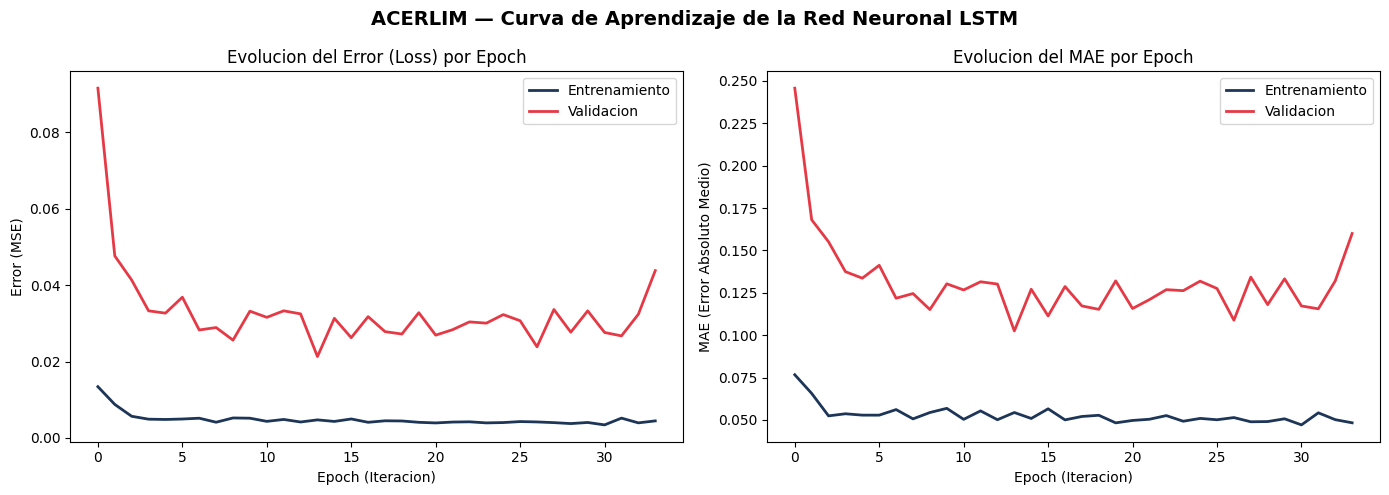

Grafico guardado como: curva_aprendizaje_lstm.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACERLIM — Curva de Aprendizaje de la Red Neuronal LSTM',
             fontsize=14, fontweight='bold')

# -- Grafico 1: Evolucion del Error (Loss) --
axes[0].plot(historial.history['loss'], label='Entrenamiento', color='#1D3557', linewidth=2)
axes[0].plot(historial.history['val_loss'], label='Validacion', color='#E63946', linewidth=2)
axes[0].set_title('Evolucion del Error (Loss) por Epoch')
axes[0].set_xlabel('Epoch (Iteracion)')
axes[0].set_ylabel('Error (MSE)')
axes[0].legend()

# -- Grafico 2: Evolucion del MAE --
axes[1].plot(historial.history['mae'], label='Entrenamiento', color='#1D3557', linewidth=2)
axes[1].plot(historial.history['val_mae'], label='Validacion', color='#E63946', linewidth=2)
axes[1].set_title('Evolucion del MAE por Epoch')
axes[1].set_xlabel('Epoch (Iteracion)')
axes[1].set_ylabel('MAE (Error Absoluto Medio)')
axes[1].legend()

plt.tight_layout()
plt.savefig('curva_aprendizaje_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como: curva_aprendizaje_lstm.png')

---
## SECCION 9 — Visualizacion de Predicciones

Comparacion grafica entre la demanda real y las predicciones generadas por la red neuronal LSTM.

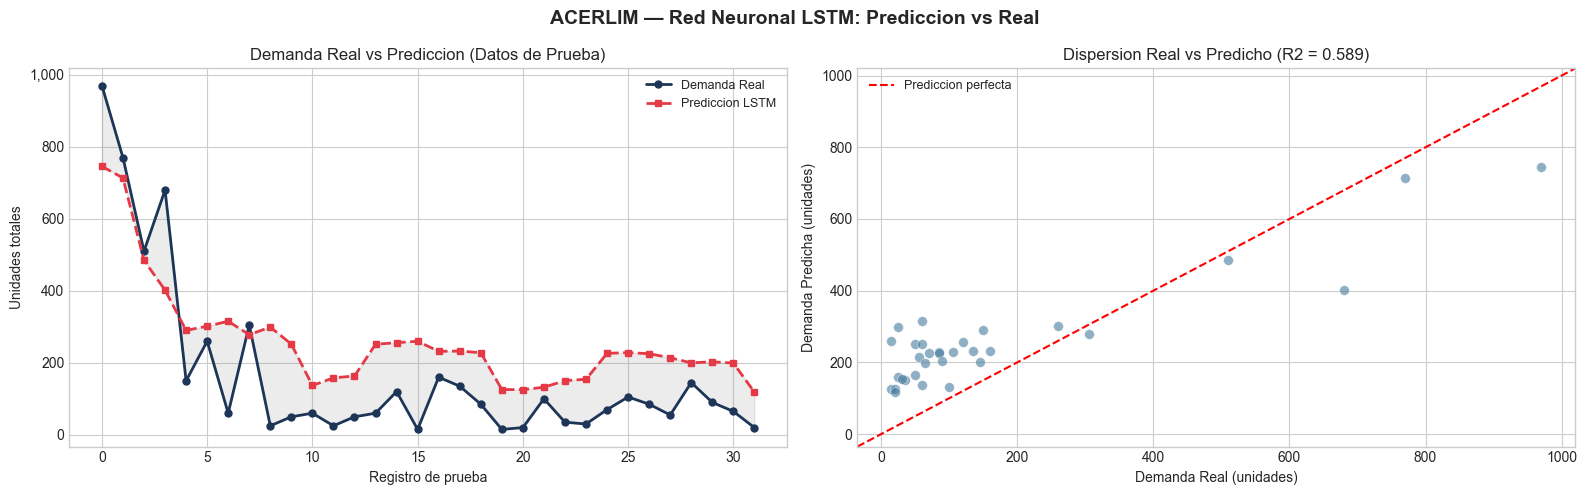

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ACERLIM — Red Neuronal LSTM: Prediccion vs Real',
             fontsize=14, fontweight='bold')

# -- Grafico 1: Lineas Real vs Predicho --
axes[0].plot(range(len(Y_prueba)), Y_prueba,
             marker='o', label='Demanda Real', color='#1D3557',
             linewidth=2, markersize=5)
axes[0].plot(range(len(Y_prueba)), predicciones_test,
             marker='s', label='Prediccion LSTM', color='#E63946',
             linewidth=2, linestyle='--', markersize=5)
axes[0].fill_between(range(len(Y_prueba)),
                     Y_prueba, predicciones_test,
                     alpha=0.15, color='gray')
axes[0].set_title('Demanda Real vs Prediccion (Datos de Prueba)')
axes[0].set_xlabel('Registro de prueba')
axes[0].set_ylabel('Unidades totales')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# -- Grafico 2: Scatter Real vs Predicho --
axes[1].scatter(Y_prueba, predicciones_test, alpha=0.6,
                color='#457B9D', s=50, edgecolors='white', linewidth=0.5)
lim_min = min(Y_prueba.min(), predicciones_test.min()) - 50
lim_max = max(Y_prueba.max(), predicciones_test.max()) + 50
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlim(lim_min, lim_max)
axes[1].set_ylim(lim_min, lim_max)
axes[1].set_xlabel('Demanda Real (unidades)')
axes[1].set_ylabel('Demanda Predicha (unidades)')
axes[1].set_title(f'Dispersion Real vs Predicho (R2 = {r2_test:.3f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('prediccion_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECCION 10 — Analisis del Error de Prediccion

In [ ]:
errores = Y_prueba - predicciones_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACERLIM — Analisis del Error (Red Neuronal LSTM)',
             fontsize=14, fontweight='bold')

# -- Histograma de errores --
axes[0].hist(errores, bins=15, color='#457B9D', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='#E63946', linestyle='--', linewidth=2, label='Error = 0')
axes[0].axvline(x=np.mean(errores), color='orange', linestyle='-',
                linewidth=2, label=f'Error promedio = {np.mean(errores):.1f}')
axes[0].set_title('Distribucion del Error')
axes[0].set_xlabel('Error (unidades)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# -- Errores por registro --
axes[1].bar(range(len(errores)), errores,
            color=['#E63946' if e < 0 else '#2A9D8F' for e in errores],
            alpha=0.8, edgecolor='white')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Error por Registro de Prueba')
axes[1].set_xlabel('Registro de prueba')
axes[1].set_ylabel('Error (unidades)')

from matplotlib.patches import Patch
ley = [Patch(facecolor='#2A9D8F', label='Subestimacion'),
       Patch(facecolor='#E63946', label='Sobreestimacion')]
axes[1].legend(handles=ley, fontsize=8)

plt.tight_layout()
plt.savefig('error_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Error promedio        : {np.mean(errores):>8.2f} unidades')
print(f'Desviacion del error  : {np.std(errores):>8.2f} unidades')

---
## SECCION 11 — Comparacion Final: Random Forest vs Red Neuronal LSTM

Tabla comparativa de ambos modelos utilizados para predecir la demanda de calaminas de ACERLIM.

COMPARACION FINAL DE MODELOS
Metrica                     Random Forest            LSTM
------------------------------------------------------------
MAE (unidades)                      92.00          131.26
RMSE (unidades)                    103.74          148.19
R2                                  0.798           0.589


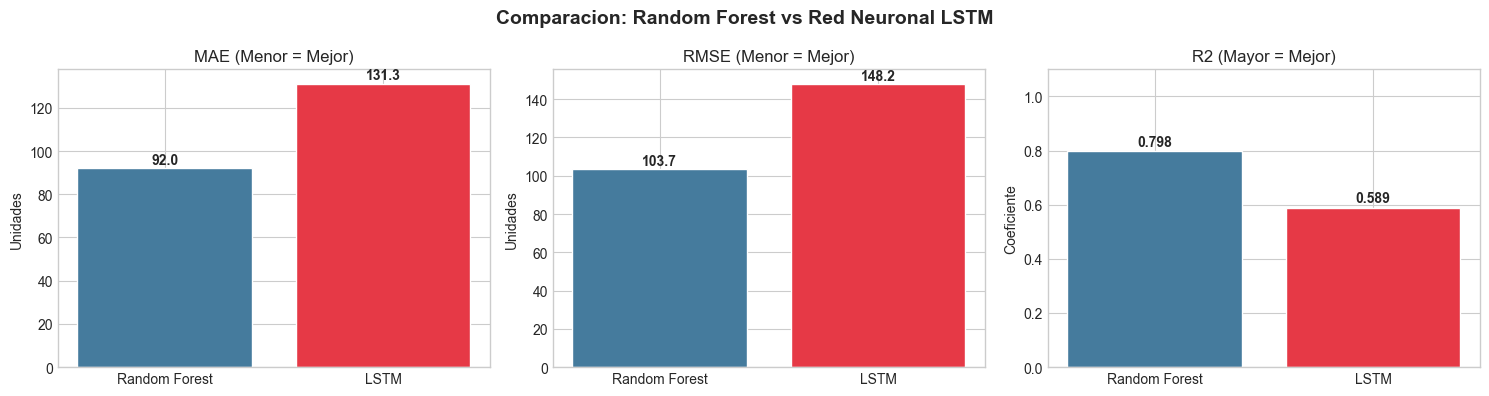


CONCLUSION: Random Forest obtiene mejor resultado con un R2 de 0.798 vs 0.589 de LSTM


In [10]:
# -- Metricas del modelo Random Forest (copiar de tu otro notebook) --
# Reemplaza estos valores con los reales si cambiaron
rf_mae  = 92.00
rf_rmse = 103.74
rf_r2   = 0.798

# -- Tabla comparativa --
print('COMPARACION FINAL DE MODELOS')
print('=' * 60)
print(f'{"Metrica":<25} {"Random Forest":>15} {"LSTM":>15}')
print('-' * 60)
print(f'{"MAE (unidades)":<25} {rf_mae:>15.2f} {mae_test:>15.2f}')
print(f'{"RMSE (unidades)":<25} {rf_rmse:>15.2f} {rmse_test:>15.2f}')
print(f'{"R2":<25} {rf_r2:>15.3f} {r2_test:>15.3f}')
print('=' * 60)

# -- Grafico comparativo --
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparacion: Random Forest vs Red Neuronal LSTM',
             fontsize=14, fontweight='bold')

modelos = ['Random Forest', 'LSTM']
colores = ['#457B9D', '#E63946']

# MAE
axes[0].bar(modelos, [rf_mae, mae_test], color=colores, edgecolor='white')
axes[0].set_title('MAE (Menor = Mejor)')
axes[0].set_ylabel('Unidades')
for i, v in enumerate([rf_mae, mae_test]):
    axes[0].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(modelos, [rf_rmse, rmse_test], color=colores, edgecolor='white')
axes[1].set_title('RMSE (Menor = Mejor)')
axes[1].set_ylabel('Unidades')
for i, v in enumerate([rf_rmse, rmse_test]):
    axes[1].text(i, v + 2, f'{v:.1f}', ha='center', fontweight='bold')

# R2
axes[2].bar(modelos, [rf_r2, r2_test], color=colores, edgecolor='white')
axes[2].set_title('R2 (Mayor = Mejor)')
axes[2].set_ylabel('Coeficiente')
axes[2].set_ylim(0, 1.1)
for i, v in enumerate([rf_r2, r2_test]):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Conclusion automatica --
if r2_test > rf_r2:
    print(f'\nCONCLUSION: La Red Neuronal LSTM supera a Random Forest con un R2 de {r2_test:.3f} vs {rf_r2:.3f}')
elif r2_test < rf_r2:
    print(f'\nCONCLUSION: Random Forest obtiene mejor resultado con un R2 de {rf_r2:.3f} vs {r2_test:.3f} de LSTM')
else:
    print(f'\nCONCLUSION: Ambos modelos obtienen resultados equivalentes con R2 = {r2_test:.3f}')